
# Lab 1:  Introduction to data manipulation and visualization


## Installing libraries then restarting jupyter

Before starting the lab, please install the following libraries: ipysigma, networkx, numpy, scikit-learn. 

After restart jupyter and continue the lab.

## Reading different data files types in Python

As you have learned during the class, data is stored in different data types according to its structure and intended use. Python has libraries for each data format, and it is important to use them correctly to avoid losing information from the files. 

**CSV** CSV files are some of the most frequent file types on the internet. The CSV library of Python allows their manipulation. Manipulating CSV files differs when the files have a header (name of columns) vs when they do not have. We show two examples below:

**CSV file without header:**
```
1744-04-01,10.411,2.403,France (Europe)
1744-05-01,12.294,1.957,France (Europe)
1744-06-01,16.077,2.002,France (Europe)
1744-07-01,17.871,2.067,France (Europe)
```

We read it as follows:

In [4]:
import csv

with open('data-GOT-EXT/got-s1-edges.csv', newline=None) as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    for row in reader:
        print(', '.join(row))

Source, Target, Weight
NED, ROBERT, 192
DAENERYS, JORAH, 154
JON, SAM, 121
LITTLEFINGER, NED, 107
NED, VARYS, 96
DAENERYS, DROGO, 91
ARYA, NED, 90
CATELYN, ROBB, 90
BRONN, TYRION, 86
CERSEI, NED, 86
CERSEI, ROBERT, 80
LITTLEFINGER, VARYS, 73
SHAE, TYRION, 73
CATELYN, NED, 69
JOFFREY, SANSA, 69
NED, PYCELLE, 68
DAENERYS, VISERYS, 66
TYRION, TYWIN, 61
JEOR, JON, 60
ROBB, THEON, 60
CERSEI, JOFFREY, 54
ARYA, SANSA, 53
BRAN, MAESTER_LUWIN, 53
JAIME, NED, 53
NED, SANSA, 49
BRAN, ROBB, 48
LORAS, RENLY, 47
CERSEI, JAIME, 46
JON, TYRION, 45
ARYA, SYRIO_FOREL, 44
JORY_CASSEL, NED, 44
JORAH, VISERYS, 43
CATELYN, TYRION, 41
ROS, THEON, 40
JOFFREY, NED, 39
CERSEI, SANSA, 36
CATELYN, WALDER, 34
DAENERYS, DOREAH, 34
JAIME, TYRION, 34
JAIME, TYWIN, 34
BENJEN, JON, 33
DAENERYS, IRRI, 32
GREATJON_UMBER, ROBB, 31
MORD, TYRION, 31
CATELYN, LYSA, 30
DOREAH, VISERYS, 30
JORAH, RAKHARO, 30
LYSA, ROBIN, 30
LYSA, TYRION, 30
NED, RENLY, 30
RENLY, ROBERT, 30
BRAN, NED, 29
BRAN, OSHA, 29
JON, NED, 29
BRAN, CATELY

When reading the input, if the newline parameter is None, the universal newline mode is enabled. Lines in the input can end in \n, \t , or \r\n, and these are translated into \n before being returned to the function. We can also use '' as newline parameter, and this option will return the end of line present in the input file without it being translated to \n. Pay attention that the delimiter parameter must match the one that is actually being used in the file. To correctly identify it, open the file in a simple text reader, such as Notepad.

**CSV file with header:**
```
dt,AverageTemperature,AverageTemperatureUncertainty,Country
1744-04-01,10.411,2.403,France (Europe)
1744-05-01,12.294,1.957,France (Europe)
1744-06-01,16.077,2.002,France (Europe)
1744-07-01,17.871,2.067,France (Europe)
```

We read it as follows:

In [7]:
import csv

with open('data-GOT-EXT/got-s1-edges.csv', newline=None) as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        print(row['Source'], row['Target'], row['Weight'])

NED ROBERT 192
DAENERYS JORAH 154
JON SAM 121
LITTLEFINGER NED 107
NED VARYS 96
DAENERYS DROGO 91
ARYA NED 90
CATELYN ROBB 90
BRONN TYRION 86
CERSEI NED 86
CERSEI ROBERT 80
LITTLEFINGER VARYS 73
SHAE TYRION 73
CATELYN NED 69
JOFFREY SANSA 69
NED PYCELLE 68
DAENERYS VISERYS 66
TYRION TYWIN 61
JEOR JON 60
ROBB THEON 60
CERSEI JOFFREY 54
ARYA SANSA 53
BRAN MAESTER_LUWIN 53
JAIME NED 53
NED SANSA 49
BRAN ROBB 48
LORAS RENLY 47
CERSEI JAIME 46
JON TYRION 45
ARYA SYRIO_FOREL 44
JORY_CASSEL NED 44
JORAH VISERYS 43
CATELYN TYRION 41
ROS THEON 40
JOFFREY NED 39
CERSEI SANSA 36
CATELYN WALDER 34
DAENERYS DOREAH 34
JAIME TYRION 34
JAIME TYWIN 34
BENJEN JON 33
DAENERYS IRRI 32
GREATJON_UMBER ROBB 31
MORD TYRION 31
CATELYN LYSA 30
DOREAH VISERYS 30
JORAH RAKHARO 30
LYSA ROBIN 30
LYSA TYRION 30
NED RENLY 30
RENLY ROBERT 30
BRAN NED 29
BRAN OSHA 29
JON NED 29
BRAN CATELYN 28
CATELYN JAIME 28
CATELYN RODRIK 28
DAENERYS QOTHO 28
JOFFREY ROBERT 28
JON MAESTER_AEMON 28
DROGO VISERYS 27
JAIME JORY_CASSEL 

**Exercise 1** Using the library CSV examples (https://docs.python.org/3/library/csv.html) create two output files (one with header and one without) containing the temperature in France today, in addition to the previous temperature values.  

In [10]:
import csv
from datetime import date

historical_rows = [
    ['1744-04-01', '10.411', '2.403', 'France (Europe)'],
    ['1744-05-01', '12.294', '1.957', 'France (Europe)'],
    ['1744-06-01', '16.077', '2.002', 'France (Europe)'],
    ['1744-07-01', '17.871', '2.067', 'France (Europe)'],
]

today = date.today().isoformat()
today_temp = '9'
today_uncertainty = '1.5'  # Exemple d'incertitude

# 1. Fichier sans header
with open('france_temperatures_noheader.csv', 'w', newline='') as csvfile :
    writer = csv.writer(csvfile)
    for row in historical_rows:
        writer.writerow(row)
    writer.writerow([today, today_temp, today_uncertainty, 'France (Europe)'])

# 2. Fichier avec header
with open('france_temperatures_withheader.csv', 'w', newline='') as csvfile:
    fieldnames = ['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    for row in historical_rows:
        writer.writerow({
            'dt': row[0],
            'AverageTemperature': row[1],
            'AverageTemperatureUncertainty': row[2],
            'Country': row[3]
        })
    writer.writerow({
        'dt': today,
        'AverageTemperature': today_temp,
        'AverageTemperatureUncertainty': today_uncertainty,
        'Country': 'France (Europe)'
    })
print("Fichiers créés : france_temperatures_noheader.csv et france_temperatures_withheader.csv")

Fichiers créés : france_temperatures_noheader.csv et france_temperatures_withheader.csv


**JSON** Another very frequent file type is the JSON. JSON files can be read easily using the json library. 

Example of JSON file:

```
{
  "temperatures": [
    {"Country": "France (Europe)", "dt": "1744-04-01", "AverageTemperature": 10.411},
    {"Country": "France (Europe)", "dt": "1744-05-01", "AverageTemperature": 12.294},
    {"Country": "France (Europe)", "dt": "1744-06-01", "AverageTemperature": 16.077},
    {"Country": "France (Europe)", "dt": "1744-07-01", "AverageTemperature": 17.871}
  ]
}
```
We read it as follows:

In [9]:
import json

with open('example.json') as jsonfile:
    data = json.load(jsonfile)
    print(data)

FileNotFoundError: [Errno 2] No such file or directory: 'example.json'

**Exercise 2** Similarly as above, create a new json file by adding the temperature of today. 

In [11]:
import json
from datetime import date

# Données historiques
historical_data = {
    "temperatures": [
        {"Country": "France (Europe)", "dt": "1744-04-01", "AverageTemperature": 10.411},
        {"Country": "France (Europe)", "dt": "1744-05-01", "AverageTemperature": 12.294},
        {"Country": "France (Europe)", "dt": "1744-06-01", "AverageTemperature": 16.077},
        {"Country": "France (Europe)", "dt": "1744-07-01", "AverageTemperature": 17.871}
    ]
}

# Ajouter la température d'aujourd'hui
aujourd_hui = {
    "Country": "France (Europe)",
    "dt": date.today().isoformat(),
    "AverageTemperature": 9
}
historical_data["temperatures"].append(aujourd_hui)

# Sauvegarder dans un nouveau fichier JSON
with open("france_temperatures_today.json", "w") as jsonfile:
    json.dump(historical_data, jsonfile, indent=2)

print("Fichier JSON créé : france_temperatures_today.json")

Fichier JSON créé : france_temperatures_today.json


## Manipulating and visualizing data using Pandas

Pandas is a Python library for data manipulation and analysis, it is particularly useful for manipulating numerical tables and time series.

The name is inspired from the term "panel data", an econometrics term for data sets that include observations over multiple time periods for the same individuals, as well as a play on the phrase "Python data analysis" [Wikipedia].

With pandas we can achieve many of the same data manipulations over tables as in SQL, but it can be much slower or even impossible to use with very large datasets,
as the library keeps all the information in the RAM. However, when the dataset is not very large, it can be interesting to use pandas, especially if we want to
preprocess the data to use it with machine learning algorithms.

In the following, we will give a small tutorial on Pandas, inspired from https://www.learndatasci.com/tutorials/python-pandas-tutorial-complete-introduction-for-beginners/

There are two important objects in pandas: Series and DataFrame.

A Series is a column, and a DataFrame is a multi-dimensional table made up of a collection of Series.

### Creating DataFrames

The easiest way to create a DataFrame is using a dictionary:

In [14]:
import pandas as pd

data = {
    'apples': [3, 2, 0, 1],
    'oranges': [0, 3, 7, 2]
}

# And then pass it to the pandas DataFrame constructor:

purchases = pd.DataFrame(data)

purchases 

,apples,oranges
0,3,0
1,2,3
2,0,7
3,1,2


Each (key, value) item in data corresponds to a column in the resulting DataFrame.

The Index of this DataFrame was given to us on creation as the numbers 0-3, but we could also create our own when we initialize the DataFrame.

Let's have customer names as our index:

In [130]:
purchases = pd.DataFrame(data, index=['June', 'Robert', 'Lily', 'David'])

purchases

,apples,oranges
June,3,0
Robert,2,3
Lily,0,7
David,1,2


So now we could locate a customer's order by using their name:

In [128]:
purchases.loc['June']

apples     9
oranges    0
Name: June, dtype: int64

### Reading data from CSVs

With CSV files all you need is a single line to load in the data. Below we read a CSV file containing countries temperatures over time, from the 1700 to the 2000. 

In [41]:
temperatures_df = pd.read_csv('GlobalLandTemperaturesByCountry.csv', header=0)

temperatures_df

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland
...,...,...,...,...
577457,2013-05-01,19.059,1.022,Zimbabwe
577458,2013-06-01,17.613,0.473,Zimbabwe
577459,2013-07-01,17.000,0.453,Zimbabwe
577460,2013-08-01,19.759,0.717,Zimbabwe


If your csv is too large, you can view just a few lines:

.head() - first lines

.tail() - last lines:

You can get more info on your dataframe using the command:

In [52]:
temperatures_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.6 MB


Another useful attribute is .shape, which outputs just a tuple of (rows, columns):

In [62]:
temperatures_df.shape

(577462, 4)

We can also select certain columns from our dataframe: 

In [63]:
temperatures_df[["Country"]]

,Country
0,Åland
1,Åland
2,Åland
3,Åland
4,Åland
...,...
577457,Zimbabwe
577458,Zimbabwe
577459,Zimbabwe
577460,Zimbabwe


In [64]:
temperatures_df[["Country", "dt"]]

,Country,dt
0,Åland,1743-11-01
1,Åland,1743-12-01
2,Åland,1744-01-01
3,Åland,1744-02-01
4,Åland,1744-03-01
...,...,...
577457,Zimbabwe,2013-05-01
577458,Zimbabwe,2013-06-01
577459,Zimbabwe,2013-07-01
577460,Zimbabwe,2013-08-01


You can also add a condition on the rows that are returned:

In [65]:
temperatures_df[temperatures_df["AverageTemperature"] >= 12]

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
8,1744-07-01,15.342,1.410,Åland
79,1750-06-01,12.408,1.204,Åland
80,1750-07-01,16.683,1.184,Åland
81,1750-08-01,17.076,0.996,Åland
92,1751-07-01,15.660,0.966,Åland
...,...,...,...,...
577456,2013-04-01,21.142,0.495,Zimbabwe
577457,2013-05-01,19.059,1.022,Zimbabwe
577458,2013-06-01,17.613,0.473,Zimbabwe
577459,2013-07-01,17.000,0.453,Zimbabwe


In [81]:
temperatures_df[(temperatures_df["AverageTemperature"] >= 12) & (temperatures_df["AverageTemperature"] < 17)]

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year,Month
8,1744-07-01,15.342,1.410,Åland,1744,07
79,1750-06-01,12.408,1.204,Åland,1750,06
80,1750-07-01,16.683,1.184,Åland,1750,07
92,1751-07-01,15.660,0.966,Åland,1751,07
93,1751-08-01,15.689,1.144,Åland,1751,08
...,...,...,...,...,...,...
577423,2010-07-01,16.668,0.410,Zimbabwe,2010,07
577434,2011-06-01,16.939,0.599,Zimbabwe,2011,06
577435,2011-07-01,15.803,0.447,Zimbabwe,2011,07
577446,2012-06-01,16.631,0.277,Zimbabwe,2012,06


In pandas we can use functions that are very similar to SQL functions. For more details see here: https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_sql.html# 

For example, we can count how many measurements we have per country:

In [82]:
temperatures_df.groupby("Country").size()

Country
Afghanistan       2106
Africa            1965
Albania           3239
Algeria           2721
American Samoa    1761
                  ... 
Western Sahara    2721
Yemen             1653
Zambia            1965
Zimbabwe          1965
Åland             3239
Length: 243, dtype: int64

Or the average temperature in a country:

In [103]:
avg_temp = temperatures_df.groupby("Country").agg({"AverageTemperature":"mean"})

avg_temp 

,AverageTemperature
Country,
Afghanistan,14.045007
Africa,24.074203
Albania,12.610646
Algeria,22.985112
American Samoa,26.611965
...,...
Western Sahara,22.319818
Yemen,26.253597
Zambia,21.282956


You can also apply function on the columns: https://www.geeksforgeeks.org/apply-a-function-to-each-row-or-column-in-dataframe-using-pandas-apply/ 

**Exercise 3** Extract from the column dt two new columns named Year and Month. 

In [87]:
# Solution Exercise 3

def year(date_complete) :
    return date_complete[0:4]

def month(date_complete) :
    return date_complete[5:7]

temperatures_df['Year'] = temperatures_df['dt'].apply(year)

temperatures_df['Month'] = temperatures_df['dt'].apply(month)

temperatures_df

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,Year,Month
0,1743-11-01,4.384,2.294,Åland,1743,11
1,1743-12-01,NaN,NaN,Åland,1743,12
2,1744-01-01,NaN,NaN,Åland,1744,01
3,1744-02-01,NaN,NaN,Åland,1744,02
4,1744-03-01,NaN,NaN,Åland,1744,03
...,...,...,...,...,...,...
577457,2013-05-01,19.059,1.022,Zimbabwe,2013,05
577458,2013-06-01,17.613,0.473,Zimbabwe,2013,06
577459,2013-07-01,17.000,0.453,Zimbabwe,2013,07
577460,2013-08-01,19.759,0.717,Zimbabwe,2013,08


## Simple visualizations of tabular data in Python

Pandas is great because we can use it easily with Matplotlib, the Python library for visualizations. 
For a good introduction with the types of visualizations that are possible, go through this tutorial:
https://pandas.pydata.org/docs/user_guide/visualization.html To better understand examples, try running them in this notebook.

Below we show a few examples on the dataset on temperature. 

In [104]:
import matplotlib
import matplotlib.pyplot as plt

avg_temp.info() # note that the names of the countries are not longer listed in the Country column, but as the index of the Dataframe. 

<class 'pandas.DataFrame'>
Index: 243 entries, Afghanistan to Åland
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AverageTemperature  242 non-null    float64
dtypes: float64(1)
memory usage: 3.8+ KB


In [105]:
avg_temp = avg_temp.reset_index() # we need to use this function so that the Country becomes a normal column again and we can use it in other operations

avg_temp

,Country,AverageTemperature
0,Afghanistan,14.045007
1,Africa,24.074203
2,Albania,12.610646
3,Algeria,22.985112
4,American Samoa,26.611965
...,...,...
238,Western Sahara,22.319818
239,Yemen,26.253597
240,Zambia,21.282956
241,Zimbabwe,21.117547


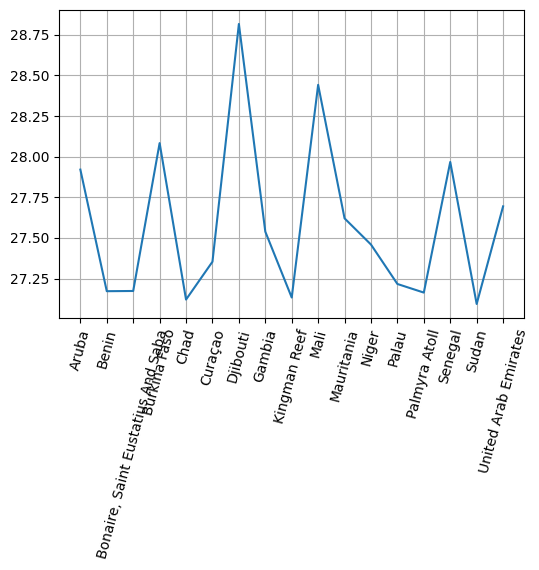

In [110]:
fig, ax = plt.subplots(figsize = (6, 4))
ax.grid()
hot_countries = avg_temp[avg_temp["AverageTemperature"]>27].reset_index()
plt.plot(hot_countries["Country"], hot_countries["AverageTemperature"])
ax.tick_params(axis='x', labelrotation = 75) # we rotate the names of the countries so that they are visible
plt.show()

**Exercise 4** Visualize how the average world temperature has changed over the timeline measured in the file, from 1743 to 2013. For this use the file GlobalLandTemperaturesByCountry.csv. 

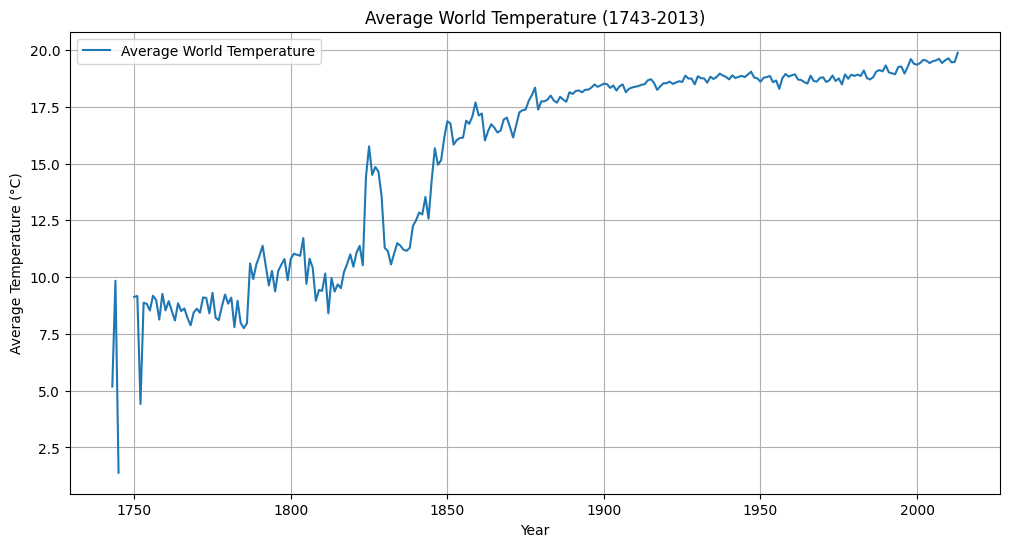

In [111]:
# Solution Exercise 4
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('GlobalLandTemperaturesByCountry.csv')
# Convert date to datetime
df['dt'] = pd.to_datetime(df['dt'])
# Group by year and calculate the mean temperature
world_temp = df.groupby(df['dt'].dt.year)['AverageTemperature'].mean()

plt.figure(figsize=(12,6))
plt.plot(world_temp.index, world_temp.values, label='Average World Temperature')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.title('Average World Temperature (1743-2013)')
plt.legend()
plt.grid(True)
plt.show()

**Exercise 5** Visualize how the temperature has changed over the timeline measured in the file, from 1743 to 2013, for a few countries in the same plot. For example, Greenland, France, United States. For this use the file GlobalLandTemperaturesByCountry.csv.  

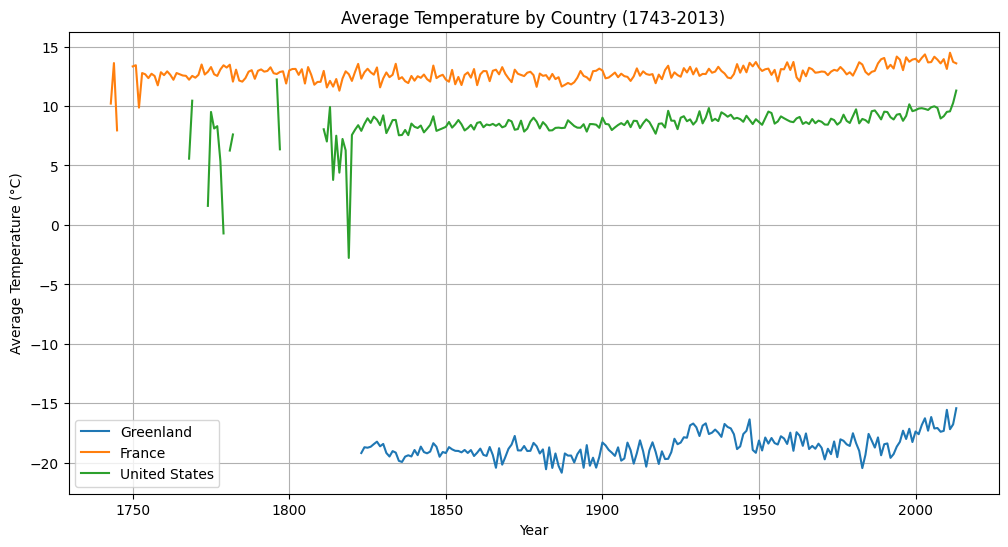

In [131]:
# Solution Exercise 5
import pandas as pd
import matplotlib.pyplot as plt

country_df = pd.read_csv('GlobalLandTemperaturesByCountry.csv')
country_df['dt'] = pd.to_datetime(country_df['dt'])

countries = ['Greenland', 'France', 'United States']

plt.figure(figsize=(12,6))
for country in countries:
    temp = country_df[country_df['Country'] == country]
    yearly_temp = temp.groupby(temp['dt'].dt.year)['AverageTemperature'].mean()
    plt.plot(yearly_temp.index, yearly_temp.values, label=country)

plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature by Country (1743-2013)')
plt.legend()
plt.grid(True)
plt.show()

## Graph library in Python: NetworkX 

**Exercise 6** Please check this tutorial and try to make a simple graph: https://networkx.org/documentation/stable/tutorial.html

In [4]:
import networkx as nx
from ipysigma import Sigma
import numpy as np

# Exercise 6: Construct a simple graph of 5 nodes and connect those 5 nodes with 7 edges.
G = nx.Graph()
# Add 5 nodes
G.add_nodes_from([1, 2, 3, 4, 5])
# Add 7 edges
edges = [(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 5), (5, 1)]
G.add_edges_from(edges)


### Game of Thrones character interaction
You will find in the TP archive a dataset about the interaction of the characters in Game of Thrones, per season. 

**Exercise 7** Create a NetworkX graph from one of the seasons, adding also the weight of edges. Check if you have created if you created correctly the graph, for example like this:

print(G.number_of_nodes())

print(G.number_of_edges())

print(G.adj['NED']) # for the first season

For reading or writing a csv file, you can use the python csv library we saw last time.


In [18]:
import pandas as pd

df = pd.read_csv('data-GOT-EXT/got-s1-edges.csv')
G = nx.Graph()
G.add_nodes_from(df["Source"].values)
G.add_edges_from(df[["Source", "Target"]].values, weight=df["Weight"].values)
print(G.number_of_nodes(), G.number_of_edges())

102 449


**Exercise 8**  Compute the average shortest path length between GoT characters to see if Westeros is a "Small World."

In [23]:
avg_path_length = nx.average_shortest_path_length(G)
avg_path_length

2.5507668413900215

**Exercise 9** Create a new graph per season and retrieve the top 10 nodes according to a node centrality measure https://networkx.org/documentation/stable/reference/algorithms/centrality.html . Does the nodes'importance change over the seasons, is it important to observe the evolution of a graph over time? 
Plot the results for a few nodes over the seasons using matplotlib. Here is a small tutorial on how to do this: https://www.geeksforgeeks.org/how-to-plot-a-time-series-in-matplotlib/

Once you have done this for one centrality measure (e.g. degree centrality), do it also for others (betweeness, eigenvalue). Do we observe different characters in the top 10 or the same characters but with other positions, if we change the centrality measure? Why is this?

**Exercise 10**  Compute communities in the Decodex graph using:
- the Louvain algorithm https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html, 
- clique percolation https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.kclique.k_clique_communities.html (experiment with different k values)
- the Girvan Newman algorithm https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.centrality.girvan_newman.html

Do the communities above overlap with some characteristics of the nodes? For example they reflect the political orientation or the fiability? Evaluate this by computing the purity of the communities. 

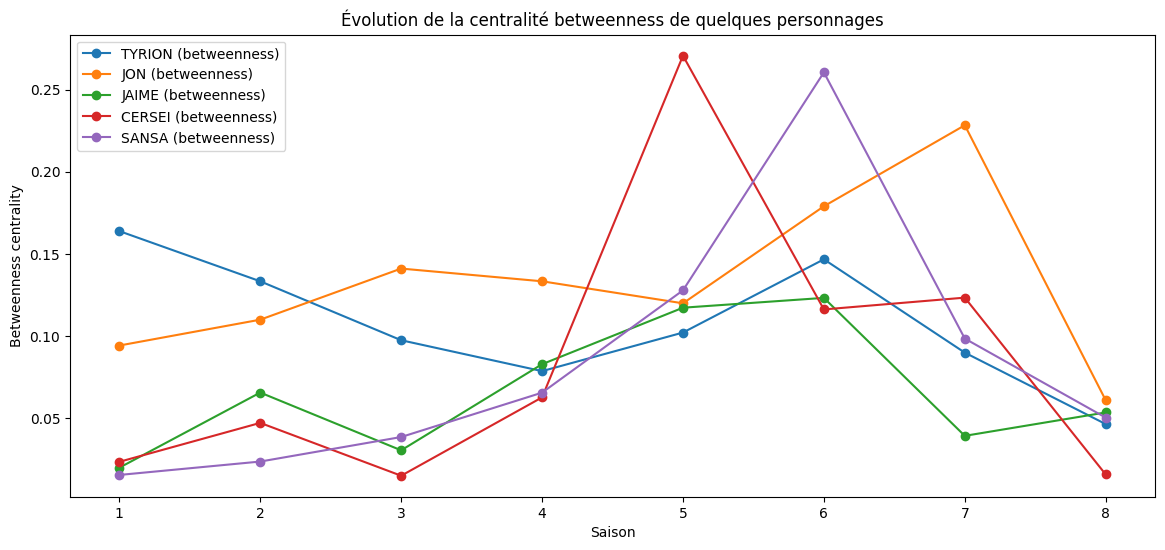

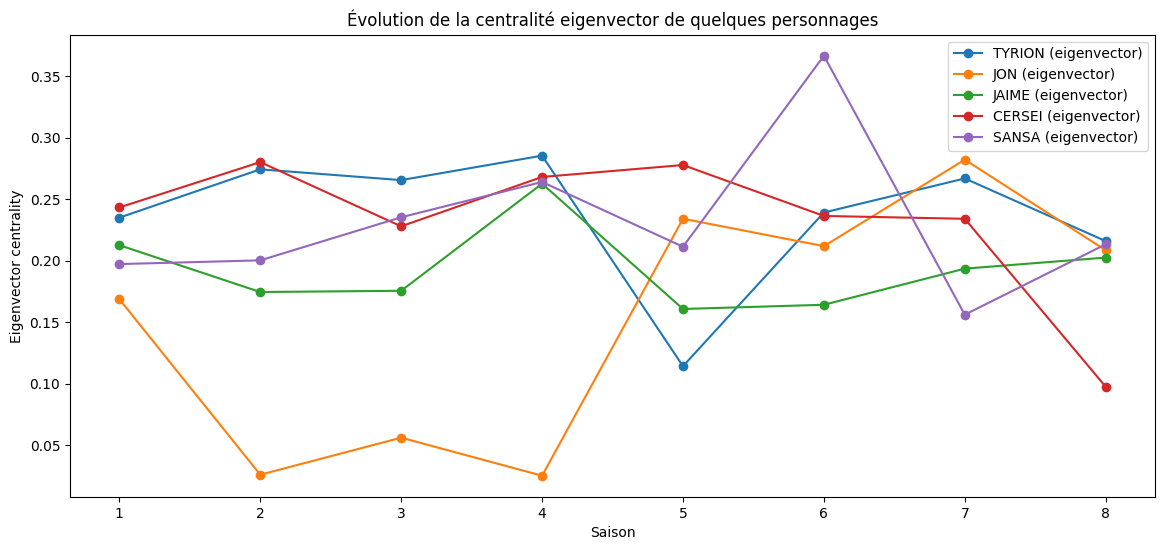

Saison 1 - Top 10 betweenness: ['NED', 'TYRION', 'ROBERT', 'CATELYN', 'ROBB', 'JON', 'DAENERYS', 'ARYA', 'JEOR', 'WALDER']
Saison 1 - Top 10 eigenvector: ['NED', 'ROBERT', 'CATELYN', 'CERSEI', 'TYRION', 'ROBB', 'JOFFREY', 'JAIME', 'LITTLEFINGER', 'ARYA']
Saison 2 - Top 10 betweenness: ['TYRION', 'ARYA', 'JON', 'ROBB', 'JOFFREY', 'NED', 'CATELYN', 'JAIME', 'TYWIN', 'THEON']
Saison 2 - Top 10 eigenvector: ['JOFFREY', 'CERSEI', 'TYRION', 'STANNIS', 'TYWIN', 'LITTLEFINGER', 'ROBB', 'SANSA', 'CATELYN', 'NED']
Saison 3 - Top 10 betweenness: ['ROBB', 'NED', 'ROBERT', 'BRAN', 'JON', 'TYWIN', 'CATELYN', 'SAM', 'TYRION', 'DAENERYS']
Saison 3 - Top 10 eigenvector: ['TYWIN', 'ROBB', 'TYRION', 'JOFFREY', 'SANSA', 'CERSEI', 'CATELYN', 'OLENNA', 'LORAS', 'PYCELLE']
Saison 4 - Top 10 betweenness: ['NED', 'STANNIS', 'JOFFREY', 'JON', 'VARYS', 'ARYA', 'BARRISTAN', 'JAIME', 'MERYN_TRANT', 'TYRION']
Saison 4 - Top 10 eigenvector: ['TYRION', 'JOFFREY', 'CERSEI', 'SANSA', 'JAIME', 'TYWIN', 'OBERYN', 'MACE',

In [ ]:
# Exercice 9 - Centralité betweenness et eigenvector
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

seasons = range(1, 9)
top_nodes_betweenness = {}
top_nodes_eigenvector = {}
centrality_betweenness = {}
centrality_eigenvector = {}

for season in seasons:
    df = pd.read_csv(f'data-GOT-EXT/got-s{season}-edges.csv')
    G = nx.Graph()
    G.add_nodes_from(df["Source"].values)
    G.add_edges_from(df[["Source", "Target"]].values, weight=df["Weight"].values)
    # Betweenness centrality
    betw = nx.betweenness_centrality(G, weight='Weight')
    # Eigenvector centrality
    try:
        eig = nx.eigenvector_centrality(G, weight='Weight', max_iter=1000)
    except nx.PowerIterationFailedConvergence:
        eig = {n: 0 for n in G.nodes}
    # Top 10 nodes for each measure
    top_betw = sorted(betw.items(), key=lambda x: x[1], reverse=True)[:10]
    top_eig = sorted(eig.items(), key=lambda x: x[1], reverse=True)[:10]
    top_nodes_betweenness[season] = [n for n, _ in top_betw]
    top_nodes_eigenvector[season] = [n for n, _ in top_eig]
    centrality_betweenness[season] = betw
    centrality_eigenvector[season] = eig

all_top_nodes = set()
for season in seasons:
    all_top_nodes.update(top_nodes_betweenness[season])
    all_top_nodes.update(top_nodes_eigenvector[season])
from collections import Counter
most_common_nodes = [n for n, _ in Counter([node for season in seasons for node in top_nodes_betweenness[season] + top_nodes_eigenvector[season]]).most_common(5)]

# Tracer l'évolution de la centralité pour ces personnages
plt.figure(figsize=(14, 6))
for node in most_common_nodes:
    plt.plot(seasons, [centrality_betweenness[s].get(node, 0) for s in seasons], marker='o', label=f"{node} (betweenness)")
plt.title("Évolution de la centralité betweenness de quelques personnages")
plt.xlabel("Saison")
plt.ylabel("Betweenness centrality")
plt.legend()
plt.show()

plt.figure(figsize=(14, 6))
for node in most_common_nodes:
    plt.plot(seasons, [centrality_eigenvector[s].get(node, 0) for s in seasons], marker='o', label=f"{node} (eigenvector)")
plt.title("Évolution de la centralité eigenvector de quelques personnages")
plt.xlabel("Saison")
plt.ylabel("Eigenvector centrality")
plt.legend()
plt.show()

# Afficher les top 10 pour chaque saison et chaque mesure
for season in seasons:
    print(f"Saison {season} - Top 10 betweenness:", top_nodes_betweenness[season])
    print(f"Saison {season} - Top 10 eigenvector:", top_nodes_eigenvector[season])


In [30]:
# Exercice 10 - Détection de communautés dans le graphe Decodex
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import louvain_communities, k_clique_communities, girvan_newman
import numpy as np
from collections import Counter

# Charger le graphe Decodex
g = nx.read_gexf('Decodex.gexf')

# 1. Louvain
communities_louvain = louvain_communities(g, seed=42)
print(f"Louvain: {len(communities_louvain)} communautés trouvées")

# 2. Clique percolation (k=3,4,5)
for k in [3, 4, 5]:
    comms = list(k_clique_communities(g, k))
    print(f"Clique percolation (k={k}): {len(comms)} communautés trouvées")

# 3. Girvan-Newman (premiers niveaux)
gn_gen = girvan_newman(g)
for i in range(3):
    comms = next(gn_gen)
    print(f"Girvan-Newman niveau {i+1}: {len(comms)} communautés trouvées")

# Évaluation de la pureté des communautés selon la fiabilité
# (on peut aussi le faire pour 'orientation contenu')
def compute_purity(communities, attribute):
    purities = []
    for comm in communities:
        attrs = [g.nodes[n].get(attribute, None) for n in comm]
        if attrs:
            most_common = Counter(attrs).most_common(1)[0][1]
            purity = most_common / len(attrs)
            purities.append(purity)
    return np.mean(purities)

purity_louvain = compute_purity(communities_louvain, 'fiabilité')
print(f"Pureté moyenne des communautés Louvain (fiabilité): {purity_louvain:.2f}")

# Pour la politique :
purity_louvain_politique = compute_purity(communities_louvain, 'orientation contenu')
print(f"Pureté moyenne des communautés Louvain (orientation contenu): {purity_louvain_politique:.2f}")

# On peut aussi afficher la distribution des attributs dans chaque communauté pour inspection
for i, comm in enumerate(communities_louvain[:5]):
    attrs = [g.nodes[n].get('fiabilité', None) for n in comm]
    print(f"Communauté {i+1} (taille {len(comm)}): {Counter(attrs)}")


Louvain: 107 communautés trouvées


NetworkXNotImplemented: not implemented for directed type

# Graph visualization in Python
Now that we are more familiar with graphs, let's try to visualize them! In the past, we have used Gephi: https://github.com/gephi/gephi
It is still an option, however, it is no longer regularly maintained. Given this, in this lab we will explore ipysigma, a visualization library created by Medialab in Sciences Po: https://github.com/medialab/ipysigma Go through the tutorial on the page of the ipysigma library.  

### Citation graph visualization in ipysigma
In networkx we can create graphs ourselves, but we can also read it from the disk - for example from a CSV file as you saw before, but also from files in the format gexf. Read more about it here: https://networkx.org/documentation/stable/reference/readwrite/gexf.html  In the TP we share a graph in this format called Decodex. It was created by Le Monde and contains information about news websites, their level of reliability and how they cite each other. For example, Le Monde is a node in this graph, with the properties seen below. The graph contains also edges with weights, with the source node being the citing website and the target note the cited website.

You can find it yourself if you open the file in a text editor. You will observe that it is written in XML, a format that is similar to HTML. 
The nodes in this graph can have the reliability score of ["Parodique", "Douteux", "Peu fiable", "Plutôt fiable"] 

 <node id="8ecdecba-1cf2-482e-a3a4-9dd3fb3e8a32" label="Le Monde">
        <attvalues>
          <attvalue for="catégorie" value="Média français"></attvalue>
          <attvalue for="attr_status" value="IN"></attvalue>
          <attvalue for="attr_modification" value="1498556446"></attvalue>
          <attvalue for="decodex" value="4"></attvalue>
          <attvalue for="orientation contenu" value="Autre ou non déterminé"></attvalue>
          <attvalue for="fiabilité" value="Plutôt fiable"></attvalue>
          <attvalue for="description" value="Un quotidien et site Internet d'information généraliste. Le groupe est détenu depuis 2010 par les hommes d'affaires Xavier Niel, Pierre Bergé et Matthieu Pigasse."></attvalue>
          <attvalue for="attr_home" value="http://youtube.com/channel/UCYpRDnhk5H8h16jpS84uqsA"></attvalue>
          <attvalue for="concat" value="Plutôt fiable - Média français - Autre ou non déterminé"></attvalue>
          <attvalue for="synthèse" value="Média français plutôt fiable"></attvalue>
          <attvalue for="fiabilité et orientation" value="Plutôt fiable"></attvalue>
        </attvalues>
      </node>

### Creating node partitions and using colors for analysis

Below we show how to create a complex visualization using ipysigma. We first partition the nodes according to their reliability (fiabilité) and also we give them colors according to the same attribute. 
Then we give edges colors according to the color of the target node. We position the nodes according to the partitions they belong to.
Like this, we can see how communities cite each other. We also set the size of the nodes to be proportional to their Pagerank score.
Note that the library is under development and sometimes the documentation might not be sufficiently clear. Try looking if your problem is also not mentioned in the issues of the libraries on Github: https://github.com/medialab/ipysigma/issues 
If you do not see it, but think your code should still be correct according to their instructions, create a new issue!

Note that you can click on nodes in the ipysigma visualization.

In [ ]:
# Importing a gexf graph
g = nx.read_gexf('./Decodex.gexf')
fiabilite_categories = ["Parodique", "Douteux", "Peu fiable", "Plutôt fiable"]
colors = {
    "Peu fiable": "#E74C3C",       # Red
    "Douteux": "#F1C40F",    # Yellow
    "Parodique": "#2ECC71",      # Green
    "Plutôt fiable": "#3498DB",  # Blue
    "Unknown": "#95A5A6"
    
}

partitions = {"Parodique": [], "Douteux": [], "Peu fiable": [], "Plutôt fiable": []}

# Assign colors based on 'fiabilité' attribute (if it exists)
for node in g.nodes:
    fiabilite = g.nodes[node].get("fiabilité", "Unknown")  # Default to "medium"
    g.nodes[node]["color_node"] = colors.get(fiabilite, "#95A5A6")  # Gray if unknown
    g.nodes[node]["size"] = 10  # Set a default size
    partitions[fiabilite].append(node)


# Assign edge colors based on the target node’s color
for source, target in g.edges:
    g.edges[source, target]["color_edge"] = g.nodes[target]["color_node"]


layout = {}
grid_positions = {
    "Peu fiable": (-2, -2),
     "Douteux": (-2, 2),
    "Parodique": (2, -2),
    "Plutôt fiable": (2, 2)
}

for category, nodes in partitions.items():
    base_x, base_y = grid_positions[category]
    angle_step = 2 * np.pi / max(1, len(nodes)) 
    radius = 1.5  # Spread out the nodes

    for i, node in enumerate(nodes):
        angle = i * angle_step
        layout[node] = {
            "x": base_x + radius * np.cos(angle),
            "y": base_y + radius * np.sin(angle)
        }

# Visualize with ipysigma
sigma = Sigma(
    g,
    raw_node_color="color_node",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="label",
    default_edge_type="curve",
    node_border_color_from="node",
    label_font="cursive",
    node_size=nx.pagerank(g)
)

sigma

### Exercises
11. How do reliable sources of information interact with untrusted sources in the Decoders graph, who is citing whom? 
Give a short explanation based on the above visualization.
12. How do the types of information sources interact with each other in the Decoders graph? To observe this, create a similar visualization as the above, but this type using the attribute "catégorie".
13. How does the citation network look like when we consider the political orientation of the websites? For this use the attribute "orientation contenu".
14. How does the citation network look like when we use finer partitions, for examples partitions where we have two dimensions, the reliability of the content and the political orientation?

You can do graph visualization also using the desktop application Gephi: https://gephi.org/quickstart/
The web version is less performant. 

